# Mini Tutorial on Climate Analysis

"**Climate** in a narrow sense is usually defined as the average
weather, or more rigorously as the statistical description in terms of
the mean and variability of relevant quantities over a period of time
ranging from months to thousands or millions of years. The classical
period for averaging these variables is 30 years, as defined by the
World Meteorological Organization (WMO). The relevant quantities
are most often surface variables such as temperature, precipitation
and wind. Climate in a wider sense is the state, including a statistical
description, of the climate system.

**Climate change** is a change in the state of the climate that can be
identified (e.g., by using statistical tests) by changes in the mean and/
or the variability of its properties and that persists for an extended
period, typically decades or longer. Climate change may be due to
natural internal processes or external forcings such as modulations
of the solar cycles, volcanic eruptions and persistent anthropogenic
changes in the composition of the atmosphere or in land use [...]" [(IPCC AR6 Glossary)](https://www.ipcc.ch/report/ar6/wg1/downloads/report/IPCC_AR6_WGI_AnnexVII.pdf)


The Earth’s climate is shaped by natural variations and anthropogenic influences. In order to analyse changes and anomalies, we need a reference to compare to. <br>

**Anomaly** is defined as the deviation of a variable from the long-term average of a reference period.

Reference periods (of at least 30 years) are used to create [**climate normals**](https://community.wmo.int/en/activity-areas/climate-services/climate-products-and-initiatives/wmo-climatological-normals). Climate normals (CNs) can be considered as the typical climate for the period the normals are based on and can then be used as a baseline to evaluate climate events. CNs can be calculated for all sorts of meteorological variables, e.g. near-surface air temperature, sea surface temperature, precipitation etc. CNs can be calculated from meteorological observations, reanalysis or climate model data. The World Meteorological Organization (WMO) defines standard reference periods used to calculate **climatological standard normals**, which are defined for overlapping periods updated every decade: 1971–2000, 1981–2010, 1991–2020, etc.

The **climatology** of a variable of interest is commonly understood as the longterm average (typ. 30 years) of the variable of interest.

Variations in meteorological variables occur on different timescales, such as the time scale of weather patterns, seasons, years, decades etc. Averaging over a period can thus smooth out and eliminate the signal of processes/phenomena occuring on timescales smaller than this period. **Rolling means** are a common tool to detect **trends** which might otherwise be disguised by fluctuations originating from phenomena with smaller time periods. An average is computed over a part of the timeseries (referred to as time window). The window is then moved along the timeaxis, creating an average-value for each of the points in time, e.g. the 30 years around that year. Using averaging windows of different size can help you determine the phenomena at play and help you analyse the one you are actually interested in. Thus, the method acts as a frequency filter (also see convolution). As climate is defined as the average over at least 30 years, the time window for the rolling mean of typical climate analysis is 30 years.


**Keywords** reference period - climate normal - anomaly - rolling means - trends - climatology

**Question: Which are commonly used reference periods and why?**

## Examples
### Pre-industrial climate normal of global near-surface air temperature (GSAT)
pre-industrial reference period is 1850-1900 (commonly used, e.g. IPCC AR5 and AR6)<br>
GSAT definition see atmosphere lab

In [14]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

# for catalog
import intake
import intake_esm
import gcsfs

%matplotlib inline

Read in 2m air temperature data for the period of interest

In [ ]:
path = '/mnt/clinfra-ns12127k-ns9560k-datalake/ESGF/CMIP6/CMIP/NCAR/CESM2/historical/r1i1p1f1/Amon/tas/gn/v20190308/tas_Amon_CESM2_historical_r1i1p1f1_gn_185001-201412.nc'
tas = xr.open_dataset(path)
tas_preind = tas['tas'].sel(time=slice('1850','1900')) # slice out data in time of interest

/opt/conda/envs/labs/lib/python3.11/site-packages/xarray/conventions.py:286: SerializationWarning: variable 'tas' has multiple fill values {1e+20, 1e+20} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


Weight the values according to the latitude and calculate spatial mean (area-weighted!)

In [16]:
weights = np.cos(np.deg2rad(tas.lat)) # weights for each gridcell (constant in time!)
tas_w = tas_preind.weighted(weights) # calculate weighted tas mean
GSAT_preind = tas_w.mean(("lon", "lat")) # calculate spatial mean

Calculate the average in time:
You can use the xarray function groupby() to group the data by year (specify time.year) and then to create the average of each year with the function mean(). The resulting object contains for each year from 1850 to 1900 the average annual global mean surface air temperature.

In [17]:
GSAT_preind_yrl = GSAT_preind.groupby('time.year').mean(keep_attrs=True)

In a last step, we want to create the average of the yearly-mean global mean near-surface air temperature for the reference period. We can do this by applying the function mean() and specify the dimension year as the dimension to be averaged.

In [ ]:
GSAT_preind_normal = GSAT_preind_yrl.mean(dim="year", keep_attrs=True)

Inspect

In [ ]:
GSAT_preind_normal

<xarray.DataArray 'tas' ()> Size: 8B
array(287.17531959)

### Anomaly of annual GSAT in most-recent historic period wrt preindustrial time

Obtain tas of most recent past; build area-weighted global mean

In [53]:
tas_mrp = tas['tas'].sel(time=slice('1995','2014')) # slice out data in time of interest

tas_mrp_w = tas_mrp.weighted(weights) # calculate weighted tas mean
GSAT_mrp = tas_mrp_w.mean(("lon", "lat")) # calculate spatial mean

Calculate annual averages. By first calculating the annual averages you ensure that seasonal variations are accounted for. (When dealing with data that contain gaps, this also mitigates the impact of missing data points.)

In [20]:
GSAT_mrp_yrl = GSAT_mrp.groupby('time.year').mean(keep_attrs=True)

Calculate anomalies during most recent past wrt preindustrial level

In [69]:
GSAT_anom_mrp_preind = GSAT_mrp_yrl - GSAT_preind_normal

Display

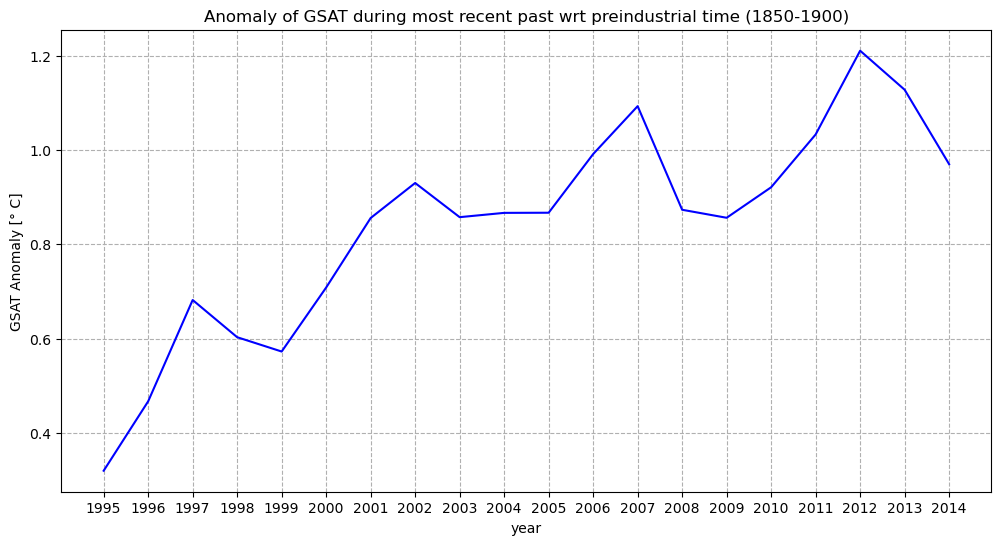

In [67]:
fig, ax = plt.subplots(1, 1, figsize = (12, 6))

ax.plot(GSAT_anom_mrp_preind.year, GSAT_anom_mrp_preind, color='blue', label='anomaly')
ax.set_xticks(GSAT_anom_mrp_preind.year)

ax.set_title('Anomaly of GSAT during most recent past wrt preindustrial time (1850-1900)')
ax.set_ylabel('GSAT Anomaly [° C]')
ax.set_xlabel('year')
#handles, labels = ax.get_legend_handles_labels()
#ax.legend(handles, labels)
ax.grid(linestyle='--')

### Anomaly of annual GSAT of entire historic experiment wrt preindustrial time

Calculate area-weighted global mean for entire period

In [61]:
# NB! the weighting function works on xarray.DataArrays, but not on xarray.Datasets
# We thus "slice out" all data, which creates a DataArray from it
tas_all = tas['tas'].sel(time=slice('1850','2014')) # slice out data in time of interest

tas_all_w = tas_all.weighted(weights) # calculate weighted tas mean
GSAT_all = tas_all_w.mean(("lon", "lat")) # calculate spatial mean

Calculate yearly averages

In [62]:
GSAT_all_yrl = GSAT_all.groupby('time.year').mean(keep_attrs=True)

Calculate anomaly

In [64]:
GSAT_anom_all_preind = GSAT_all_yrl - GSAT_preind_normal

Display

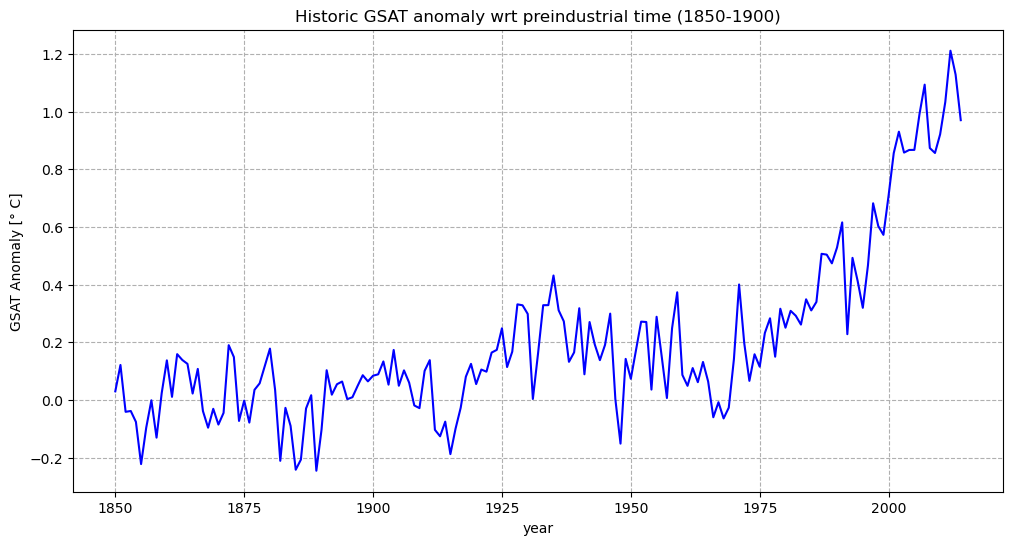

In [68]:
fig, ax = plt.subplots(1, 1, figsize = (12, 6))

ax.plot(GSAT_anom_all_preind.year, GSAT_anom_all_preind, color='blue', label='anomaly')
#ax.set_xticks(GSAT_anom_all_preind.year)

ax.set_title('Historic GSAT anomaly wrt preindustrial time (1850-1900)')
ax.set_ylabel('GSAT Anomaly [° C]')
ax.set_xlabel('year')
#handles, labels = ax.get_legend_handles_labels()
#ax.legend(handles, labels)
ax.grid(linestyle='--')

This result is a timeseries of annual GSAT anomaly wrt preindustrial levels. 

**Question: What is the average GSAT anomaly between 1850-1990?**

As discussed above, variations in meteorological variables occur on different timescales, such as the time scale of weather patterns, seasons, years, decades etc. As GSAT is a global metric, it already is somewhat cleaned for local meteorological effects. But it still contains fluctuations on smaller timescales than climatic scales. Just by eyesight you can also already tell that there is a clear climate signal towards positive GSAT anomalies during the historic period we're looking at. But lets do a trend analysis.


### GSAT Trend Analysis in Historic Period

We want to see the climatic signal, so we apply a center-value 30-year rolling mean to our timeseries. This means that around each point in time, symmetric 30 years are being averaged and stored as the 30 year rolling mean for this point as the center of the averaging window. This also means that for the first and last 15 years in the timeseries, this rolling mean is not defined, as the averaging window would reach out of your initial timeseries.

In [75]:
GSAT_roll_30yr = GSAT_anom_all_preind.rolling(year=30, center=True).mean()

Check the obtained variable, and yes, the first and last values are NaN

In [76]:
GSAT_roll_30yr

<xarray.DataArray 'tas' (year: 165)> Size: 1kB
array([            nan,             nan,             nan,             nan,
                   nan,             nan,             nan,             nan,
                   nan,             nan,             nan,             nan,
                   nan,             nan,             nan,  1.27479451e-02,
        1.76830899e-02,  1.47948565e-02,  9.13385357e-03,  9.49859332e-03,
        9.04014812e-03,  8.38586064e-03,  4.69046909e-03,  3.74617078e-03,
        8.64788730e-03, -3.16827212e-04, -8.34751678e-03, -5.27362132e-03,
       -9.95534836e-03, -1.27560020e-02, -1.47956701e-02, -1.54424764e-02,
       -1.87106038e-02, -1.58092427e-02, -9.74670725e-03, -6.57502645e-03,
       -9.32404950e-04,  3.52730761e-03,  1.64789977e-03, -1.54320407e-03,
        6.65499628e-03,  8.36938337e-03,  1.44052663e-02,  1.52327281e-02,
        1.26795416e-02,  7.81347284e-03,  5.24170156e-03,  8.68738967e-03,
        1.22679961e-02,  8.98133085e-03,  9.47044193e-03,  1.12725142e-02,
        1.48479521e-02,  1.49352747e-02,  1.70725913e-02,  2.94177965e-02,
        3.47098885e-02,  3.47881533e-02,  3.74450771e-02,  4.11013079e-02,
        4.47607735e-02,  5.29481852e-02,  5.64344093e-02,  6.03940951e-02,
        6.85812662e-02,  7.73687762e-02,  8.45082880e-02,  8.16595271e-02,
        8.25619108e-02,  9.17428005e-02,  9.69212532e-02,  1.09657117e-01,
        1.16597506e-01,  1.23683153e-01,  1.28724501e-01,  1.35164181e-01,
        1.42397746e-01,  1.40764603e-01,  1.53215155e-01,  1.63833829e-01,
...
        1.99333751e-01,  2.02868066e-01,  1.98276624e-01,  1.99607055e-01,
        2.00793550e-01,  1.95441170e-01,  1.92676188e-01,  1.94178887e-01,
        1.87129289e-01,  1.88647044e-01,  1.86979136e-01,  1.78086722e-01,
        1.71521223e-01,  1.59275340e-01,  1.46917901e-01,  1.37573295e-01,
        1.31034277e-01,  1.24645339e-01,  1.18775491e-01,  1.29150856e-01,
        1.26718209e-01,  1.22504866e-01,  1.23182626e-01,  1.20655586e-01,
        1.18417806e-01,  1.27763696e-01,  1.37807648e-01,  1.43606362e-01,
        1.49513112e-01,  1.54033859e-01,  1.54712785e-01,  1.54415274e-01,
        1.64846683e-01,  1.65582048e-01,  1.71918223e-01,  1.88576822e-01,
        1.97085292e-01,  2.00430296e-01,  2.15151916e-01,  2.34031345e-01,
        2.37946020e-01,  2.52307890e-01,  2.61665907e-01,  2.70182245e-01,
        2.87736325e-01,  3.10717523e-01,  3.32939388e-01,  3.52907804e-01,
        3.71784921e-01,  3.86961664e-01,  4.11387966e-01,  4.37757353e-01,
        4.61360950e-01,  4.86412375e-01,  5.11714699e-01,  5.38705401e-01,
        5.62807161e-01,  5.80799870e-01,  6.03143248e-01,  6.27272995e-01,
        6.57893119e-01,  6.86771472e-01,  7.07467031e-01,             nan,
                   nan,             nan,             nan,             nan,
                   nan,             nan,             nan,             nan,
                   nan,             nan,             nan,             nan,
                   nan])
Coordinates:
  * year     (year) int64 1kB 1850 1851 1852 1853 1854 ... 2011 2012 2013 2014

Display

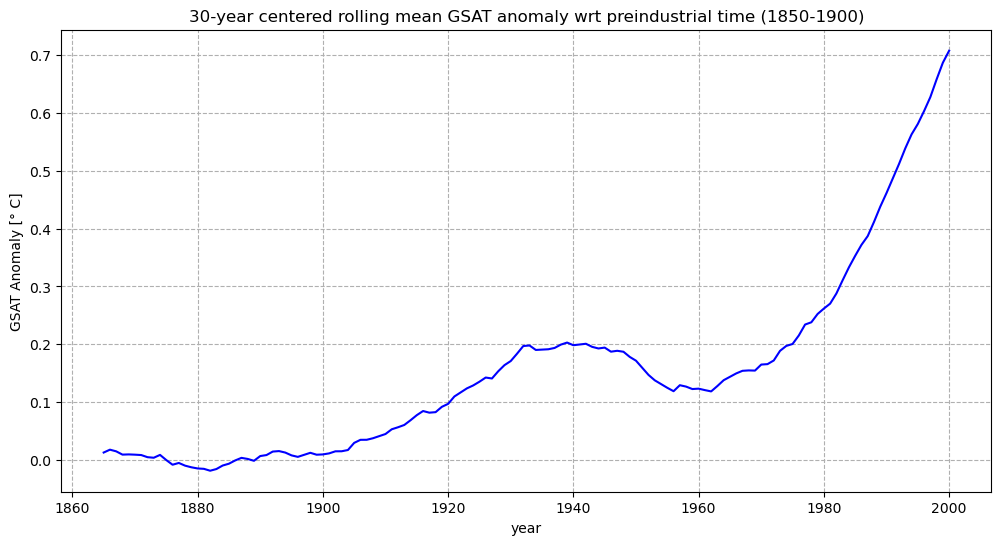

In [78]:
fig, ax = plt.subplots(1, 1, figsize = (12, 6))

ax.plot(GSAT_roll_30yr.year, GSAT_roll_30yr, color='blue', label='anomaly')
#ax.set_xticks(GSAT_anom_all_preind.year)

ax.set_title('30-year centered rolling mean GSAT anomaly wrt preindustrial time (1850-1900)')
ax.set_ylabel('GSAT Anomaly [° C]')
ax.set_xlabel('year')
#handles, labels = ax.get_legend_handles_labels()
#ax.legend(handles, labels)
ax.grid(linestyle='--')

You can now see a clear climate signal in the GSAT anomaly.

**Important!** You can calculate anomalies, trends etc on all sorts or different data. We have now analysed global annual averages, but you can also analyse say the anomaly in January temperatrues in Oslo (or, Oslo's gridcell) in the worst-case climate scenario wrt preindustrial time, or wrt to the most recent past. Become clear about what your research question is, and then consider which data you need.